In [3]:
%load_ext autoreload
%autoreload 2

In [25]:
import os
import logging

from pathlib import Path
from collections.abc import Sequence
from typing import Literal

import dotenv
import matplotlib.pyplot as plt

import torch
from torchvision.transforms.v2 import Compose, Resize, InterpolationMode, Normalize, ToDtype, ToImage
from torchvision.transforms.v2 import GaussianBlur,Compose, RandomPerspective, Resize

from diffusers import StableDiffusionImageVariationPipeline
from huggingface_hub import login


from brain_image.data import load_image_from_path, preprocess_image
from brain_image.configs import get_device
from brain_image.model import NICEModel

logging.basicConfig(level=logging.INFO)
dotenv.load_dotenv()


tok = os.environ.get("HF_API_TOKEN")
if not tok:
    raise ValueError("HF_API_TOKEN is not set. Please set it in the .env file")

login(token=tok)

In [48]:
cp_path = "logs/nice/version_38/checkpoints/nice-epoch=24-val_top1_acc=0.3790.ckpt"
nice_model = NICEModel.load_checkpoint(cp_path, compile=False)
device = get_device()
dtype = torch.float16

loader = nice_model.data_module.test_dataloader()
ex_batch = next(iter(loader))
img_latent = ex_batch["img_latent"]
eeg_data = ex_batch["eeg_data"]
img_path = ex_batch["img_path"]


/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [50]:
base_pipe = StableDiffusionImageVariationPipeline.from_pretrained(
    "lambdalabs/sd-image-variations-diffusers", 
    revision="v2.0",
    torch_dtype=torch.float16,
).to("cuda")

vae = base_pipe.vae
unet = base_pipe.unet
image_encoder = base_pipe.image_encoder
noise_scheduler = base_pipe.scheduler

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error

In [69]:
images = torch.stack([load_image_from_path(Path(p)) for p in img_path])[:4]
print("Images loaded", images.shape, images.max(), images.min(), images.dtype)

low_level_image_transform = Compose([
    ToImage(),
    ToDtype(dtype, scale=True),
    Resize(
        (512, 512),
        interpolation=InterpolationMode.BICUBIC,
        antialias=True,
    ),
])

cond_image_transform = Compose([
    ToImage(),
    ToDtype(dtype, scale=True),
    Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC,
        antialias=False,
        ),
    Normalize(
      [0.48145466, 0.4578275, 0.40821073],
      [0.26862954, 0.26130258, 0.27577711]
    ),
])


ll_pp_img = low_level_image_transform(images)
pp_img = cond_image_transform(images)
print("Images preprocessed", pp_img.shape, pp_img.dtype, pp_img.max(), pp_img.min())
print("Low level images preprocessed", ll_pp_img.shape, ll_pp_img.dtype, ll_pp_img.max(), ll_pp_img.min())

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Images preprocessed torch.Size([4, 3, 224, 224]) torch.float16 tensor(2.3477, dtype=torch.float16) tensor(-1.8486, dtype=torch.float16)
Low level images preprocessed torch.Size([4, 3, 512, 512]) torch.float16 tensor(1.0352, dtype=torch.float16) tensor(-0.0629, dtype=torch.float16)


Shapes (500, 500, 3), (224, 224, 3), (512, 512, 3)
Max 1.0, 1.056, 1.035
Min 0.0, -0.019, -0.025


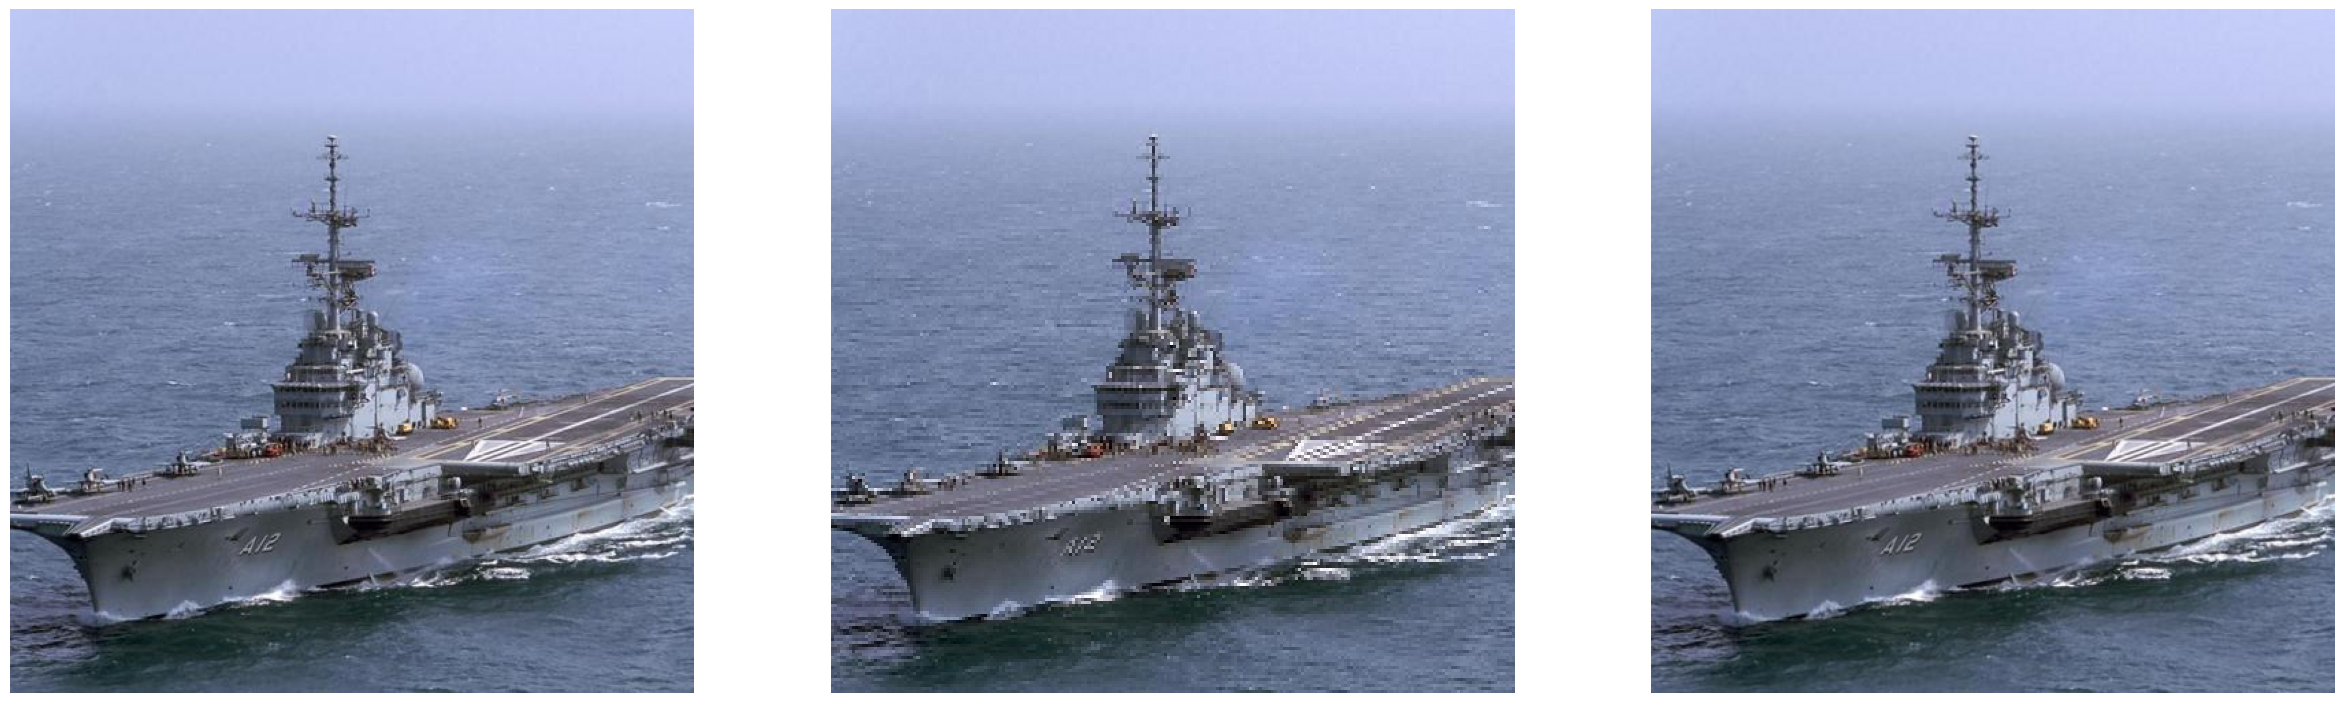

In [ ]:


def show_image(*imgs, transforms: Sequence[str] | None = None, verbose: bool = False):
    imgs = [img.detach().cpu().float() for img in imgs]
    merged_imgs = []
    for img in imgs:
        if len(img.shape) == 3:
            merged_imgs.append(img)
        elif len(img.shape) == 4:
            for i in range(img.shape[0]):
                merged_imgs.append(img[i])
        else:
            raise ValueError(f"Invalid image shape: {img.shape}")
    imgs = merged_imgs

    if transforms is None:
        transforms = ["none" for _ in imgs]
    
    for i in range(len(imgs)):
        imgs[i] = imgs[i].permute(1, 2, 0) 

        mean_vec = torch.tensor([0.48145466, 0.4578275, 0.40821073])
        std_vec = torch.tensor([0.26862954, 0.26130258, 0.27577711])

        match transforms[i]:
            case "none":
                pass
            case "unstandardize":
                # Inverse of the normalization transform   
                imgs[i] = imgs[i] * std_vec + mean_vec
            case "standardize":
                imgs[i] = (imgs[i] - mean_vec) / std_vec
            case "normalize":
                imgs[i] = imgs[i] / 255.0
            case _:
                logging.warning(f"Invalid transform: {transforms[i]}. Ignoring it.")

    if verbose:
        print("Shapes", ', '.join([str(tuple(img.shape)) for img in imgs]))
        print("Max", ', '.join([str(round(img.max().item(), 3)) for img in imgs]))
        print("Min", ', '.join([str(round(img.min().item(), 3)) for img in imgs]))

    fig, axs = plt.subplots(1, len(imgs), figsize=(10*len(imgs), 10))
    if len(imgs) == 1:
        axs = [axs]
    
    for i, img in enumerate(imgs):
        img = img.detach().cpu().float()
        
        axs[i].imshow(img)
        axs[i].axis("off")
    plt.show()

show_image(images[0], pp_img[0], ll_pp_img[0], transforms=["normalize", "unstandardize", "none"], verbose=True)
#print((images / 255.0).max(), (images / 255.0).min())

Shapes (500, 500, 3), (500, 500, 3)
Max 1.0, 0.988
Min 0.0, 0.094


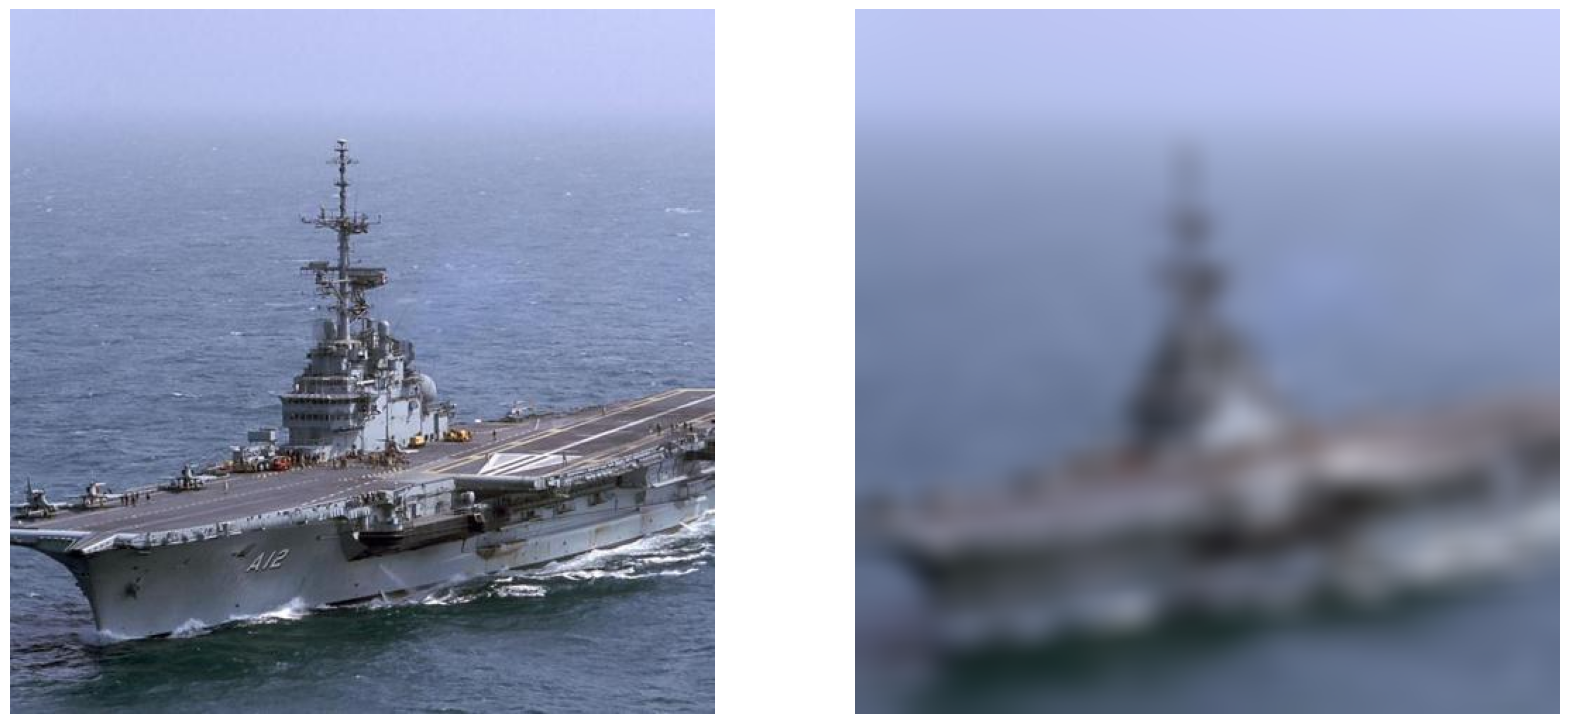

In [66]:
# We create an artificially terrible image for low level

noise_pipe = Compose([
    GaussianBlur(kernel_size=(33, 33), sigma=10.0),
])

noisy_images = noise_pipe(images)

show_image(images[0], noisy_images[0], transforms=["normalize", "normalize"], verbose=True)

In [67]:
class ReconstructionPipeline:
    def __init__(self, unet, vae, noise_scheduler, image_encoder, ):
        self.unet = unet
        self.vae = vae
        self.noise_scheduler = noise_scheduler

        #self.conditioning_image_preprocessor = low_level_image_transform
        #self.low_level_image_preprocessor = 

    def reconstruct_latents(
        self,
        conditioning_latent: torch.Tensor,   # <batch_size, 768>
        low_image_latent: torch.Tensor | None = None,  # <batch_size, 4, 64, 64>
        guidance_scale: float = 7.5,
        num_inference_steps: int = 50,
        noise_strength: float = 1.0,
        device: torch.device = get_device(),
        seed: int = 0,
        backend: Literal["stable_diffusion", "versatile_diffusion"] = "stable_diffusion",
        extra_step_kwargs: dict = {}
    ):
        if backend != "stable_diffusion":
            raise NotImplementedError(f"backend {backend} is not implemented")

        generator = torch.Generator(device=device).manual_seed(seed)

        do_classifier_free_guidance = guidance_scale > 1.0
        vae_scale_factor = 2 ** (len(self.vae.config.block_out_channels) - 1)
        height = self.unet.config.sample_size * vae_scale_factor
        width = self.unet.config.sample_size * vae_scale_factor
        channels = self.unet.config.in_channels
        batch_size = conditioning_latent.shape[0]
        latents_shape = (batch_size, channels, height // 8, width // 8)

        if backend == "stable_diffusion":
            conditioning_latent = conditioning_latent.unsqueeze(1) 

        self.noise_scheduler.set_timesteps(num_inference_steps, device=device)

        # Prepare Latents
        if noise_strength < 1.0 and low_image_latent is not None:  # Image to image reconstruction
            if low_image_latent.shape[0] != conditioning_latent.shape[0]:
                raise ValueError(
                    "low_image_latent and conditioning_latent must have the same batch size"
                )

            low_image_latent.to(device=device, dtype=conditioning_latent.dtype)

            init_timestep = min(
                int(num_inference_steps * noise_strength), num_inference_steps
            )  # Needs at least one noise step
            t_start = max(num_inference_steps - init_timestep, 0)

            timesteps = self.noise_scheduler.timesteps[t_start:]
            latent_timestep = timesteps[:1].repeat(low_image_latent.shape[0])

            init_latents = low_image_latent

            noise = torch.randn(
                latents_shape,
                generator=generator,
                device=device,
                dtype=init_latents.dtype,
            )
            latents = self.noise_scheduler.add_noise(
                init_latents, noise, latent_timestep
            )
            assert latents.shape == latents_shape, f"{latents.shape} != {latents_shape}"

        else:  # Conditioning only reconstruction
            timesteps = self.noise_scheduler.timesteps
            latents = (
                torch.randn(
                    latents_shape,
                    generator=generator,
                    device=device,
                    dtype=conditioning_latent.dtype,
                )
                * self.noise_scheduler.init_noise_sigma
            )

        if do_classifier_free_guidance:
            uncond_latent = torch.zeros_like(conditioning_latent)
            conditioning_latent = torch.cat([uncond_latent, conditioning_latent])

        # Denoising Loop
        for i, t in enumerate(timesteps):
            latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
            latent_model_input = self.noise_scheduler.scale_model_input(latent_model_input, t)

            noise_pred = self.unet(latent_model_input, t, conditioning_latent).sample

            if do_classifier_free_guidance:
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

            latents = self.noise_scheduler.step(noise_pred, t, latents, **extra_step_kwargs).prev_sample

        # Decode Latents
        reconstruction = self.vae.decode(latents / self.vae.config.scaling_factor).sample
        return reconstruction
    
    def encode_conditioning_image(self, image: torch.Tensor):
        #image_latent = image_encoder.pre
        return self.vae.encode(image.to(self.vae.device, dtype=torch.float16)).latent_dist.sample * self.vae.config.scaling_factor
    
    def encode_low_level_image(self, image: torch.Tensor):
        low_level_latent = self.vae.encode(image.to(self.vae.device, dtype=torch.float16))
        low_level_latent = low_level_latent.latent_dist.sample() * self.vae.config.scaling_factor
        return low_level_latent
    
pipe = ReconstructionPipeline(unet, vae, noise_scheduler, None)

In [ ]:
with torch.no_grad():
    print("Images loaded", images.shape, images.max(), images.min(), images.dtype)
    print("Noisy images loaded", noisy_images.shape, noisy_images.max(), noisy_images.min(), noisy_images.dtype)

    conditioning_images = images.to(device)
    low_level_images = noisy_images.to(device)

    processed_img = cond_image_transform(conditioning_images)
    processed_low_level_images = low_level_image_transform(low_level_images)

    print("Processed images", processed_img.shape, processed_img.max(), processed_img.min(), processed_img.dtype)
    print("Processed low level images", processed_low_level_images.shape, processed_low_level_images.max(), processed_low_level_images.min(), processed_low_level_images.dtype)

    conditioning_latent = image_encoder(processed_img).image_embeds
    low_level_latent = vae.encode(processed_low_level_images)
    low_level_latent = low_level_latent.latent_dist.sample() * vae.config.scaling_factor

    reconstruction = pipe.reconstruct_latents(
        conditioning_latent, 
        low_image_latent=low_level_latent, 
        noise_strength=0.5,
        guidance_scale=6,
        num_inference_steps=50
    )

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Noisy images loaded torch.Size([4, 3, 500, 500]) tensor(252, dtype=torch.uint8) tensor(4, dtype=torch.uint8) torch.uint8
Processed images torch.Size([4, 3, 224, 224]) tensor(2.3477, device='cuda:0', dtype=torch.float16) tensor(-1.8486, device='cuda:0', dtype=torch.float16) torch.float16
Processed low level images torch.Size([4, 3, 512, 512]) tensor(0.9883, device='cuda:0', dtype=torch.float16) tensor(0.0152, device='cuda:0', dtype=torch.float16) torch.float16


Shapes (224, 224, 3), (512, 512, 3)
Max 1.056, 0.972
Min -0.019, -0.624


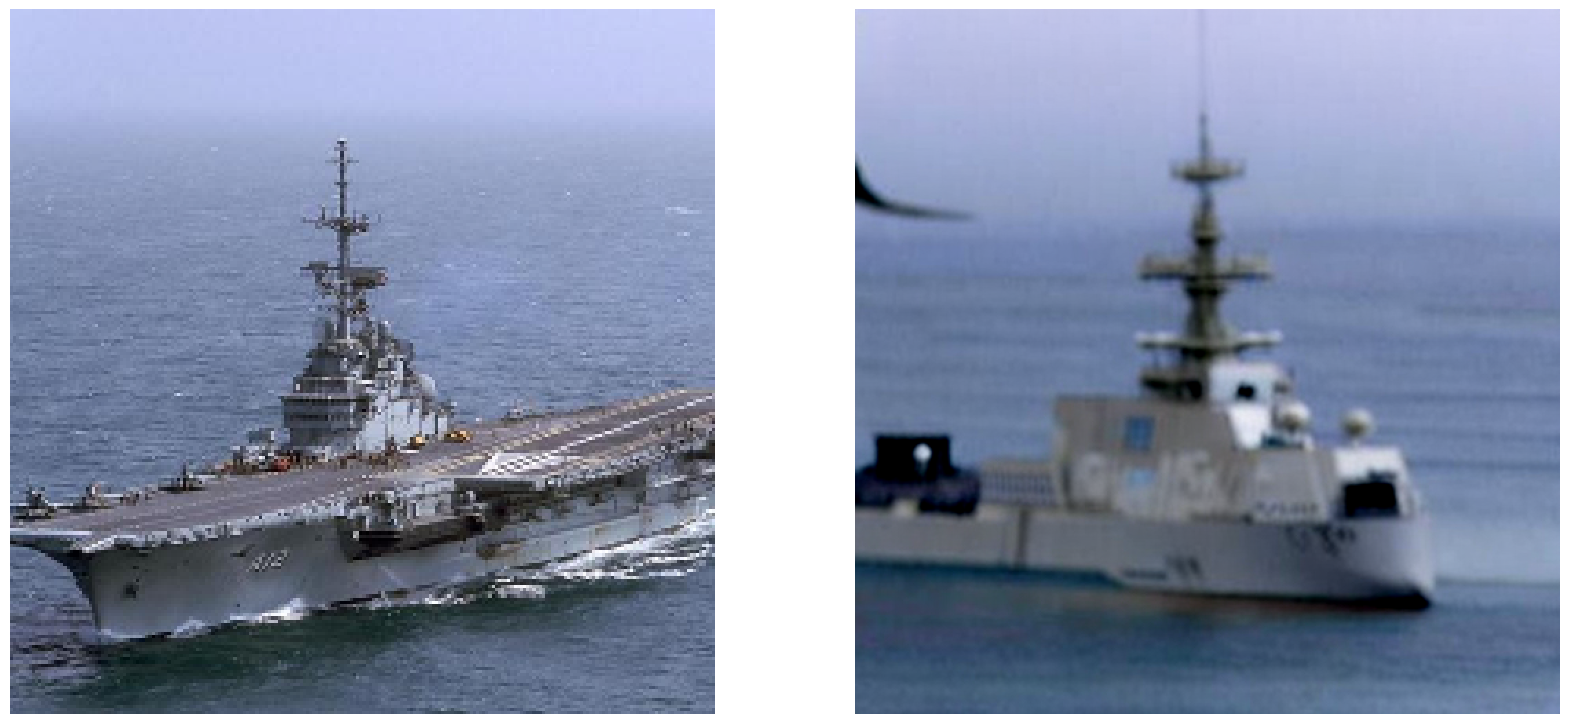

Shapes (224, 224, 3), (512, 512, 3)
Max 0.955, 0.811
Min -0.049, -0.886


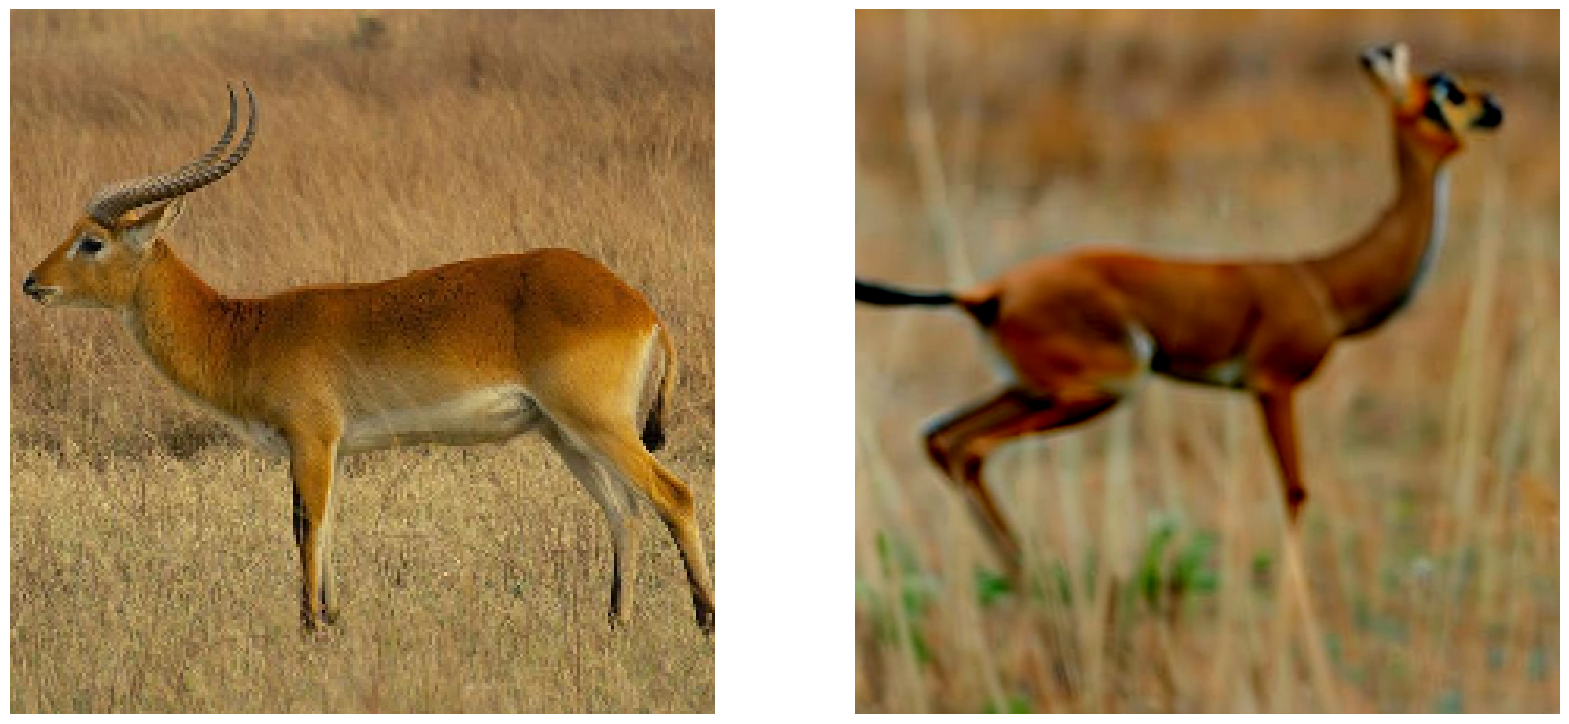

Shapes (224, 224, 3), (512, 512, 3)
Max 1.023, 0.973
Min -0.078, -0.521


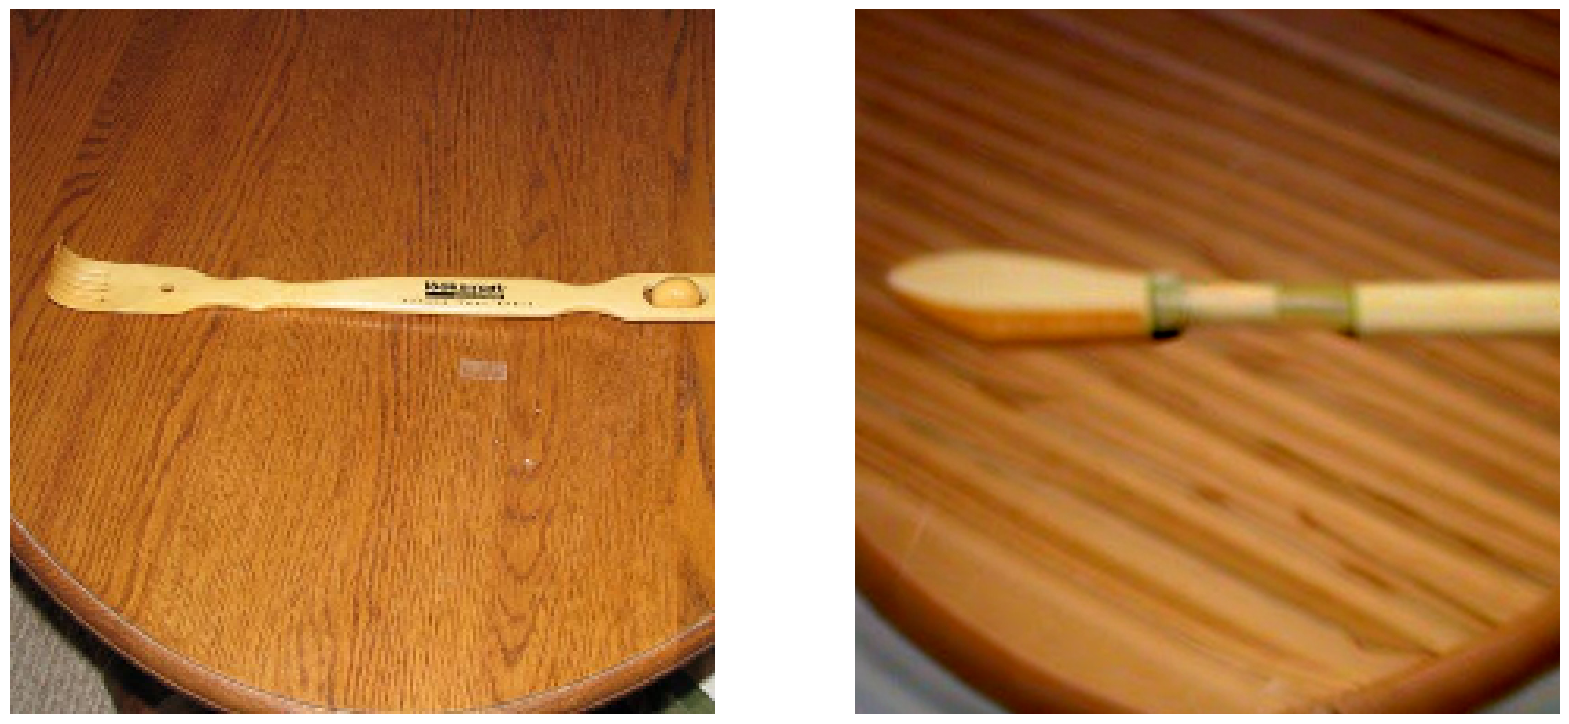

Shapes (224, 224, 3), (512, 512, 3)
Max 1.046, 1.0
Min -0.038, -0.847


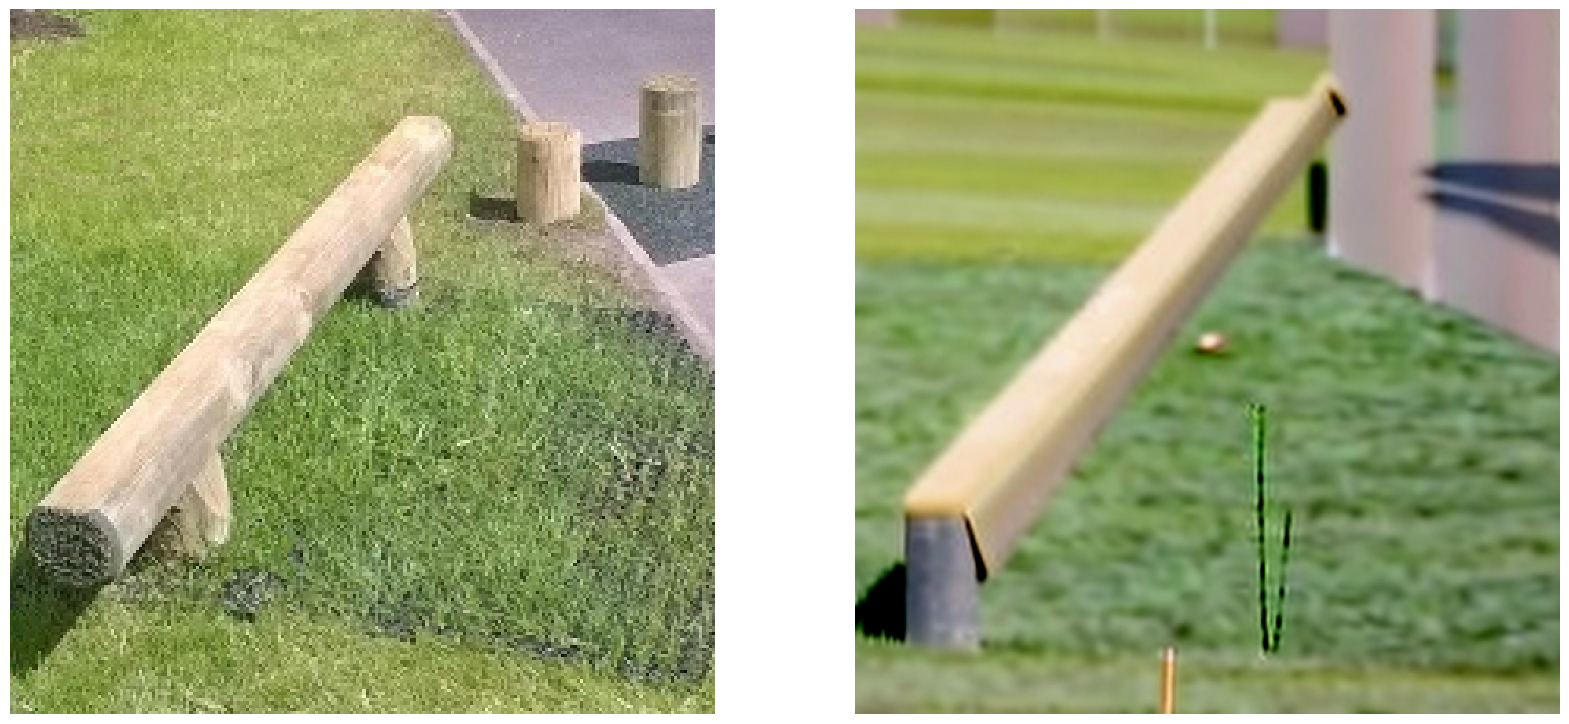

In [71]:
for i in range(4):
    show_image(pp_img[i], reconstruction[i], transforms=["unstandardize", "none"], verbose=True)

In [ ]:
# Sweep over noise strength, guidance scale, and num inference steps

noise_strength = [0.2, 0.4, 0.6, 0.8, 1.0]
guidance_scale = [2.5, 5, 7.5, 10]
num_inference_steps = [25, 50, 75]

exp_num = 0
for noise_strength in noise_strength:
    for guidance_scale in guidance_scale:
        for num_stpes in num_inference_steps:
            exp_num += 1
            print(f"================================================")
            print(f"Experiment {exp_num}:")
            print(f"Noise strength: {noise_strength}")
            print(f"Guidance scale: {guidance_scale}")
            print(f"Number of inference steps: {num_stpes}")
            print(f"================================================")

            with torch.no_grad():
            reconstruction = pipe.reconstruct_latents(
                conditioning_latent[:1], 
                low_image_latent=low_level_latent[:1], 
                noise_strength=noise_strength,
                guidance_scale=guidance_scale,
                num_inference_steps=num_stpes
            )

            show_image(pp_img[0], reconstruction[0], standardize=[True, False], verbose=True)

Experiment 1:
Noise strength: 0.2
Guidance scale: 2.5
Number of inference steps: 25


NameError: name 'pipe' is not defined